# CosmoFit — CPL (w0waCDM) MCMC Analysis (4-dataset, publication-quality)


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/main/examples/cpl_mcmc_tfd42.ipynb)


This notebook is an end-to-end walkthrough of **CosmoFit**: fitting the
**CPL (Chevallier–Polarski–Linder) dark-energy model**,

$$w(z) = w_0 + w_a \frac{z}{1+z},$$

to real cosmological data — Cosmic Chronometers, DESI BAO, Pantheon+
supernovae, **and Planck's CMB distance priors** — in a single joint
MCMC fit, with a long, publication-quality chain, convergence
diagnostics, the standard publication-style figures, and a model
comparison against flat $\Lambda$CDM.

This is a longer-running variant of `cpl_mcmc_analysis.ipynb`: adding
Planck breaks the $H_0$–$\Omega_m$–$r_d$ geometric degeneracy that a
late-time-only (CC+DESI+Pantheon) fit can't resolve on its own, which
is what lets $r_d$ and $\Omega_b$ join the free parameters here instead
of being held fixed -- see section 3. The MCMC settings are also pushed
well past "a few minutes" (`nwalkers=64`, `nsteps=12000`) for a
publication-grade chain, evaluated across every CPU core available
(section 4) since a single-core chain this long would take a long time.

**Running this notebook:** open it in Google Colab and choose
*Runtime → Run all*. The first cell installs CosmoFit and its
dependencies; everything after that just works. Locally, it assumes
CosmoFit is already installed (`pip install -e .` from the repository
root).

**Runtime:** the MCMC cells are CPU-bound and, even parallelized across
all cores, take on the order of 15-30 minutes total (highly
machine-dependent -- Colab's free tier typically gives you 2 cores,
so expect longer there than on a many-core workstation).


## 1. Setup

Installs CosmoFit + dependencies when running in Google Colab. If you're running this locally from a cloned repository with CosmoFit already installed (`pip install -e .`), this cell does nothing.

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("CosmoFit"):
        !git clone --quiet -b dev https://github.com/salihyesil59/CosmoFit.git
    %cd CosmoFit
    !pip install -q -e .

    # The editable install above runs in a subprocess, so the .pth /
    # editable-finder file it writes isn't picked up by *this*
    # already-running kernel without a restart. Without this, `import
    # CosmoFit` can resolve to the bare repo checkout directory
    # instead (same name as the package, and `/content` is on
    # sys.path in Colab) -- an empty namespace package with none of
    # LCDM/CPL/Fitter defined, raising a confusing "unknown location"
    # ImportError. Pointing sys.path at src/ directly sidesteps that.
    import importlib
    sys.path.insert(0, os.path.abspath("src"))
    importlib.invalidate_caches()
else:
    print("Not running in Colab -- assuming CosmoFit is already installed "
          "(pip install -e . from the repository root).")


Not running in Colab -- assuming CosmoFit is already installed (pip install -e . from the repository root).


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from CosmoFit import LCDM, CPL, Fitter
from CosmoFit.stats import model_comparison, cpl_diagnostics
from CosmoFit.data.loader import available_datasets

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
np.random.seed(0)

# ------------------------------------------------------------
# Saving figures
# ------------------------------------------------------------
# Every figure below is also written to
# examples/cpl_mcmc_tfd42_figures/<name>.svg, under the same names
# the plain-script version (cpl_mcmc_tfd42.py) uses, so the two
# produce an interchangeable set.
#
# A notebook has no __file__, and the kernel's working directory
# depends on where it was started -- the repo root from VS Code,
# examples/ from a Jupyter Lab launched there, /content on Colab --
# so locate the directory rather than assuming one of those.

from pathlib import Path

_cwd = Path.cwd()
_base = (
    _cwd / "examples"
    if (_cwd / "examples" / "cpl_mcmc_tfd42.ipynb").exists()
    else _cwd
)

FIGURE_DIR = _base / "cpl_mcmc_tfd42_figures"
FIGURE_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# Saving the chains
# ------------------------------------------------------------
# Both MCMC runs below pass `save=CHAIN_DIR / "<name>.h5"`, which
# writes the chain to disk as it is sampled and reads it back
# instead of re-sampling it next time. That matters most in a
# notebook: reopening this file, restarting the kernel, or adding
# one more figure at the bottom would otherwise mean re-running
# hours of MCMC to get back to where you were.
#
# Delete this directory to force genuinely fresh chains.

CHAIN_DIR = _base / "cpl_mcmc_tfd42_chains"
CHAIN_DIR.mkdir(exist_ok=True)


#: Artists with more vertices than this are rasterized inside the
#: SVG rather than written out as vector paths. The chain plot draws
#: nwalkers x nsteps points per parameter -- 64 x 12000 x 6 = 4.6M
#: vertices here -- and SVG stores every one as text, which produced
#: a 58 MB file that browsers and editors choke on. Rasterizing just
#: those traces takes it to a few MB while axes, ticks, labels and
#: legends stay vector, i.e. still sharp at any zoom in a paper.
RASTERIZE_ABOVE = 5000

#: Resolution for the rasterized parts only. Everything that carries
#: text or fine structure remains vector regardless.
RASTER_DPI = 150


def savefig(fig, name):
    """
    Save `fig` as cpl_mcmc_tfd42_figures/<name>.svg.

    SVG is vector, so these stay sharp at any zoom and drop straight
    into a paper. Two deliberate differences from the plain-script
    version of this helper in cpl_mcmc_tfd42.py:

    * it does *not* close the figure -- closing it would suppress
      the inline rendering that makes the notebook worth reading;
    * it rasterizes very dense artists first (see RASTERIZE_ABOVE).
    """

    for ax in fig.get_axes():
        for artist in [*ax.get_lines(), *ax.collections]:
            try:
                n_points = len(artist.get_xdata())
            except AttributeError:
                offsets = artist.get_offsets()
                n_points = 0 if offsets is None else len(offsets)
            if n_points > RASTERIZE_ABOVE:
                artist.set_rasterized(True)

    path = FIGURE_DIR / f"{name}.svg"
    fig.savefig(path, format="svg", bbox_inches="tight", dpi=RASTER_DPI)
    print(f"saved {path.name} ({path.stat().st_size / 1e6:.2f} MB)")

    return fig


print(f"Figures will be saved to {FIGURE_DIR}/")
print(f"Chains will be saved to {CHAIN_DIR}/")


Figures will be saved to /home/talos/CosmoFit/examples/cpl_mcmc_tfd42_figures/


### A note on seeding

Every `run_mcmc(..., seed=...)` call below gets its own seed, derived
from one `MASTER_SEED` via `numpy.random.SeedSequence.spawn()` --
`numpy`'s own recommended way to generate multiple *statistically
independent* random streams from a single reproducible source,
rather than reusing the same literal seed everywhere. This buys full
reproducibility (`MASTER_SEED=42` is enough to regenerate every chain
below identically) without ever risking a shared/correlated random
stream across what are supposed to be independent fits.

To be clear about what seeding does and doesn't affect: it only fixes
*which* pseudo-random numbers `emcee`'s proposal mechanism draws, not
whether samples within a chain are independent of each other. `emcee`'s
affine-invariant ensemble sampler correlates walkers by construction
(each proposal uses the complementary half of the ensemble) -- that's
a property of the *method*, not the seed, and it's exactly what
`fit.convergence()`'s autocorrelation time $\tau$ and `n_eff` (section
5) are for: they're what actually certifies the posterior samples used
below are, in effect, independent draws, regardless of which seed
produced them.

In [3]:
MASTER_SEED = 42

_seed_names = ["cpl_joint", "lcdm_joint"]
SEEDS = {
    name: int(child.generate_state(1)[0])
    for name, child in zip(
        _seed_names, np.random.SeedSequence(MASTER_SEED).spawn(len(_seed_names)),
    )
}
SEEDS

{'cpl_joint': 2684470948, 'lcdm_joint': 4091952314}

## 2. Datasets

CosmoFit ships with four built-in observational datasets, and this
notebook uses all of them: Cosmic Chronometers, DESI BAO, and
Pantheon+ (the late-time, purely background-expansion probes), plus
Planck's compressed CMB distance priors ($R$, $\ell_A$,
$\omega_b h^2$) -- included directly in the joint fit this time,
rather than as a separate independent check (compare with
`cpl_mcmc_analysis.ipynb`, which keeps them separate).

In [4]:
available_datasets()

{'cc': ['favale2023'],
 'desi': ['desi2024'],
 'sdss_bao': ['dr12+dr16'],
 'pantheon': ['pantheon+sh0es'],
 'des_sn5yr': ['des-sn5yr'],
 'fsigma8': ['gold2018'],
 's8': ['kids1000', 'des_y3'],
 'planck': ['planck2018']}

## 3. Building the CPL fit

Free parameters: $H_0$, $\Omega_m$, $w_0$, $w_a$, $r_d$, $\Omega_b$.

With only CC+DESI+Pantheon, $r_d$ can't be separated from $H_0$ in the
BAO distance ratios ($D_M/r_d$, etc.) without an independent handle on
the absolute distance scale -- that's why `cpl_mcmc_analysis.ipynb`
holds it fixed. Planck's $R$ and $\ell_A$ provide exactly that handle
(they pin down $H_0 \cdot D_M(z_*)$ and $D_M(z_*)/r_s(z_*)$
directly), so with Planck in the fit $r_d$ becomes constrainable and
joins the free parameters -- the standard approach in the DESI 2024
CPL papers this reproduces the spirit of.

$\Omega_b$ joins them too: Planck's $\omega_b h^2$ data point
constrains it directly, and holding $\Omega_b$ fixed while still
scoring the fit against that data point would let its constraining
power leak entirely into $H_0$ instead of being properly marginalized
over its own uncertainty.

In [5]:
fit = Fitter(
    model=CPL,
    datasets=["cc", "desi", "pantheon", "planck"],
    free_params=["H0", "Omega_m", "w0", "wa", "rd", "Omega_b"],
    initial={
        "H0": 67.4,
        "Omega_m": 0.315,
        "w0": -1.0,
        "wa": 0.0,
        "rd": 147.1,
        "Omega_b": 0.0493,
    },
)

fit

Fitter(model=CPL, datasets=['cc', 'desi', 'pantheon', 'planck'], free_params=['H0', 'Omega_m', 'w0', 'wa', 'rd', 'Omega_b'])

In [6]:
print(f"Total data points: {fit.n_data}")
fit.chi2_breakdown()

Total data points: 1671


{'CC': 13.3377083716049,
 'DESI': 20.712473590731655,
 'Pantheon+': 1457.4988513663411,
 'Planck': 0.711278547021772}

## 4. Running the MCMC

`Fitter.run_mcmc` wraps `emcee.EnsembleSampler`. For a publication-
quality chain we push well past the "few minutes" demo settings:
`nwalkers=64` (comfortably above the `>= 2 * ndim = 12` emcee needs,
enough for healthy mixing across 6 free parameters) and
`nsteps=12000`. Check `fit.convergence()` in the next section before
trusting the result -- if `converged` comes back `False`, that means
this chain wasn't long enough yet and `nsteps` needs to go higher
still (there's no way to know the required length ahead of time; it
depends on how correlated the actual posterior turns out to be).

`n_processes` defaults to `"auto"`, so it does not have to be passed
at all: CosmoFit sizes the worker pool itself, using every core this
process is *allowed* to run on (which is not the same as
`os.cpu_count()` inside a container, a cgroup, or a SLURM
allocation), and only when the run is long enough to earn back the
cost of starting the workers. It also detects a `define_model()`
custom model -- which cannot be shipped to a worker process -- and
quietly stays single-process instead of failing.

Worth knowing: most of the multi-core speedup no longer comes from
`n_processes` at all. The dominant per-evaluation cost, the Pantheon+
covariance solve, is now a BLAS mat-vec that threads across every
core on its own (see `data.covariance.DenseCovariance`), so even
`n_processes=1` saturates the machine. Worker processes add a further
modest gain on top. This is identical in a notebook, in VS Code, and
in a plain script -- the old note claiming multiprocessing was broken
inside Jupyter kernels was a misdiagnosis of that serial solve.

The chain itself does not depend on any of this: the proposal RNG
lives in the main process and is seeded from `seed`, so a given seed
gives bit-identical results at any `n_processes`.

`save=` is what makes a chain this long survivable in a notebook.
Every step is written to `cpl_mcmc_tfd42_chains/cpl.h5` as it is
taken, and the next call reads it back rather than sampling it
again -- so re-running this cell after a kernel restart, or
reopening the notebook next week, costs seconds instead of the full
run. `nsteps` is the *total* length to reach: leave it alone and
nothing is re-sampled; raise it to 20000 and only the missing 8000
steps are sampled, continuing the same chain. Interrupting the cell
half way keeps whatever it had already done. And because emcee's
proposal RNG state travels in the file alongside the walkers, a
chain grown over several sittings is bit-identical to the same
chain sampled in one go.

CosmoFit records the model, datasets, free parameters, priors and
fixed values in the file too, and refuses to continue a chain whose
posterior differs from the fit in front of it -- so editing the cell
above and re-running this one raises a clear error naming what
changed, instead of quietly mixing samples from two different
posteriors.

In [7]:
fit.run_mcmc(
    nwalkers=64, nsteps=12000, burnin=2000, seed=SEEDS["cpl_joint"],
    progress=True,
    save=CHAIN_DIR / "cpl.h5",
)

100%|██████████| 12000/12000 [06:15<00:00, 32.00it/s]


## 5. Convergence diagnostics

Before trusting any posterior summary or figure below, check that the
chain has actually mixed: the integrated autocorrelation time $\tau$
should be much shorter than the chain length (`converged=True` requires
at least 50$\tau$, `emcee`'s own recommended rule of thumb). Short demo
runs like this one often fall a little short of that -- rerun with more
steps if `converged` is `False` and you need publication-quality
intervals.

In [8]:
conv = fit.convergence()

for name, tau in conv["tau"].items():
    print(f"{name:>10s}:  tau = {tau:6.1f}   n_eff = {conv['n_effective'][name]:7.1f}")

print(f"\nconverged (n_steps >= 50*tau for every parameter): {conv['converged']}")

        H0:  tau =   72.7   n_eff =  8798.7
   Omega_m:  tau =   68.8   n_eff =  9305.5
        w0:  tau =   79.1   n_eff =  8087.6
        wa:  tau =   87.8   n_eff =  7292.1
        rd:  tau =   66.3   n_eff =  9660.2
   Omega_b:  tau =   73.9   n_eff =  8660.2

converged (n_steps >= 50*tau for every parameter): True


## 6. Posterior summary and best fit

In [9]:
for name, stats_ in fit.summary().items():
    print(f"{name:>10s} = {stats_['median']:8.4f}  "
          f"+{stats_['plus']:.4f} / -{stats_['minus']:.4f}")

        H0 =  67.5640  +0.7452 / -0.7406
   Omega_m =   0.3138  +0.0077 / -0.0075
        w0 =  -0.8495  +0.0694 / -0.0681
        wa =  -0.6282  +0.3019 / -0.3225
        rd = 148.0458  +0.8628 / -0.8419
   Omega_b =   0.0490  +0.0011 / -0.0011


In [10]:
result = fit.best_fit()

print("Best-fit parameters (maximum likelihood):")
for name, value in fit.best_fit_params.items():
    print(f"  {name:>10s} = {value:.4f}")

print(f"\nchi2_min = {fit.best_fit_chi2:.2f}  "
      f"({fit.n_data} data points, {fit.ndim} free parameters)")

Best-fit parameters (maximum likelihood):
          H0 = 67.5786
     Omega_m = 0.3133
          w0 = -0.8585
          wa = -0.5838
          rd = 148.0479
     Omega_b = 0.0490

chi2_min = 1480.85  (1671 data points, 6 free parameters)


## 7. MCMC diagnostics: chain trace and corner plot

Every plot in CosmoFit lives on `fit.plots` (a `plots.FitPlotter`
instance).

saved chain.svg (1.49 MB)


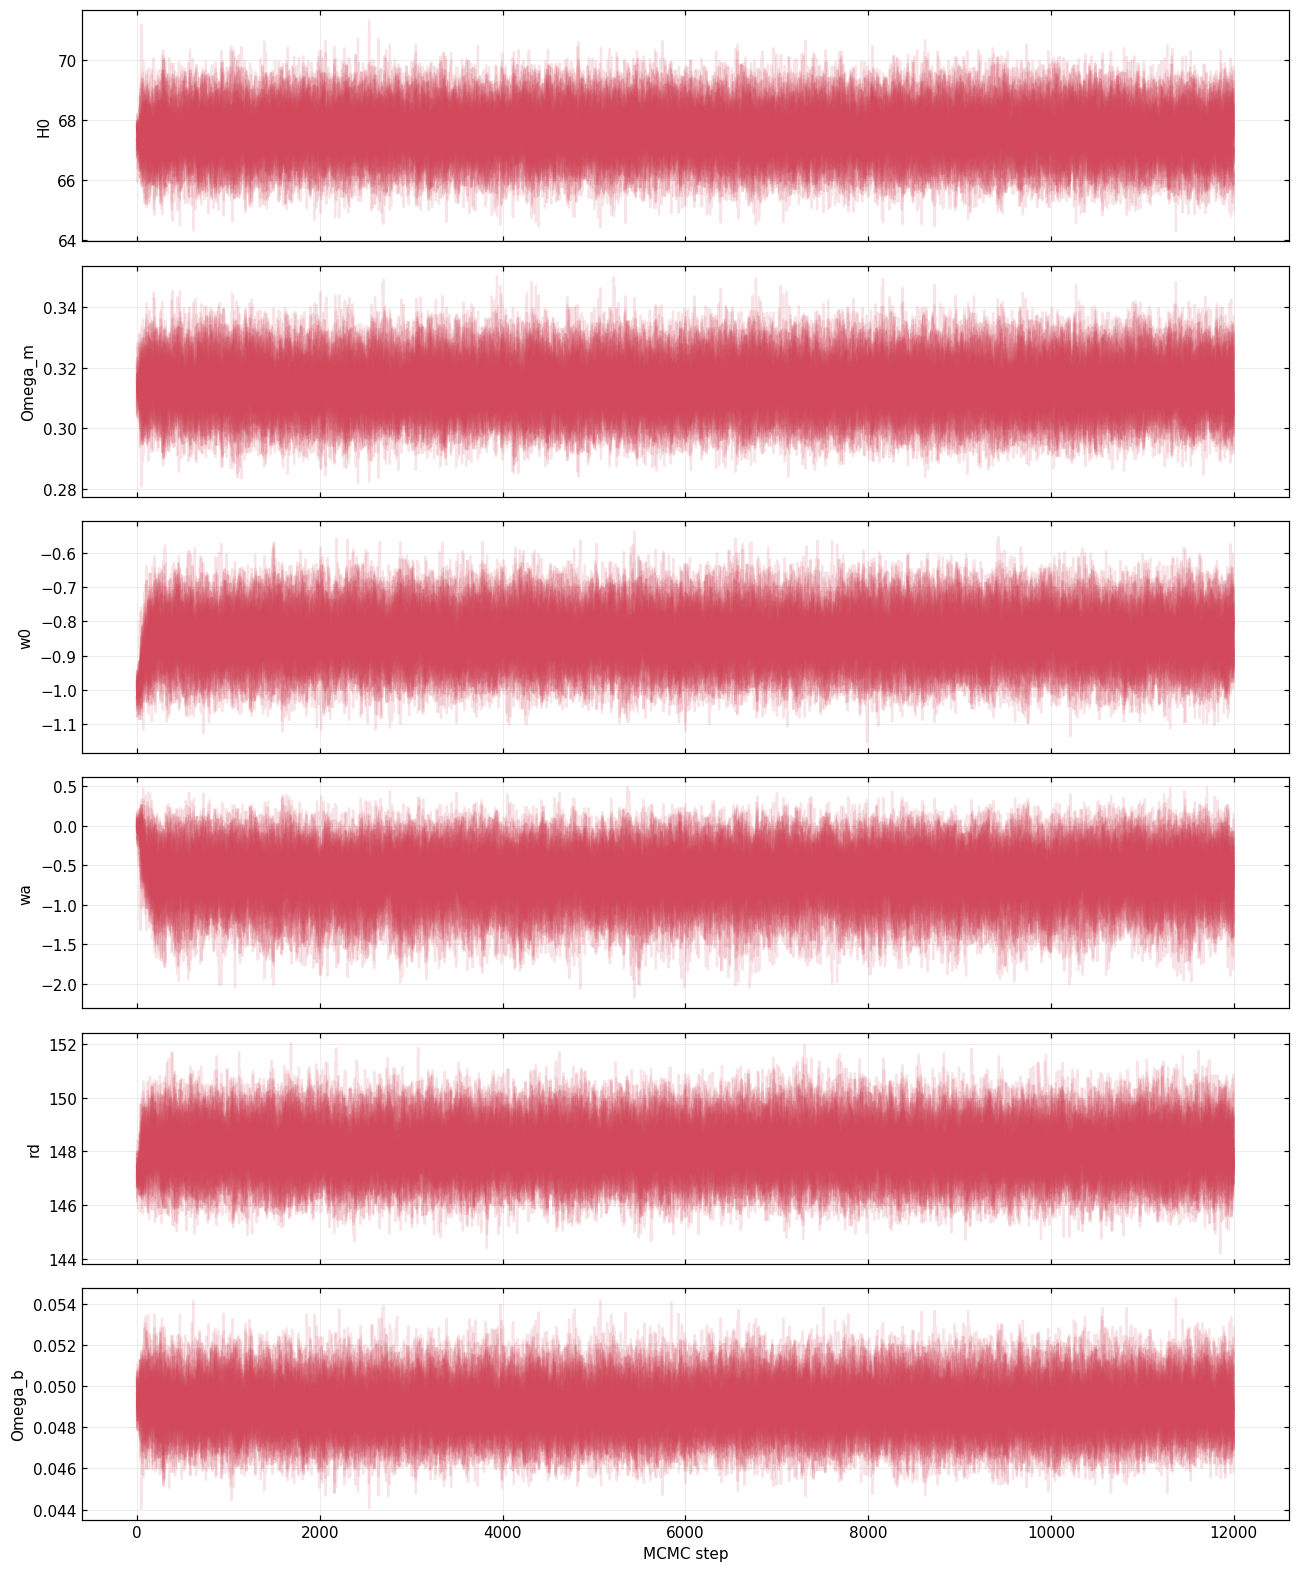

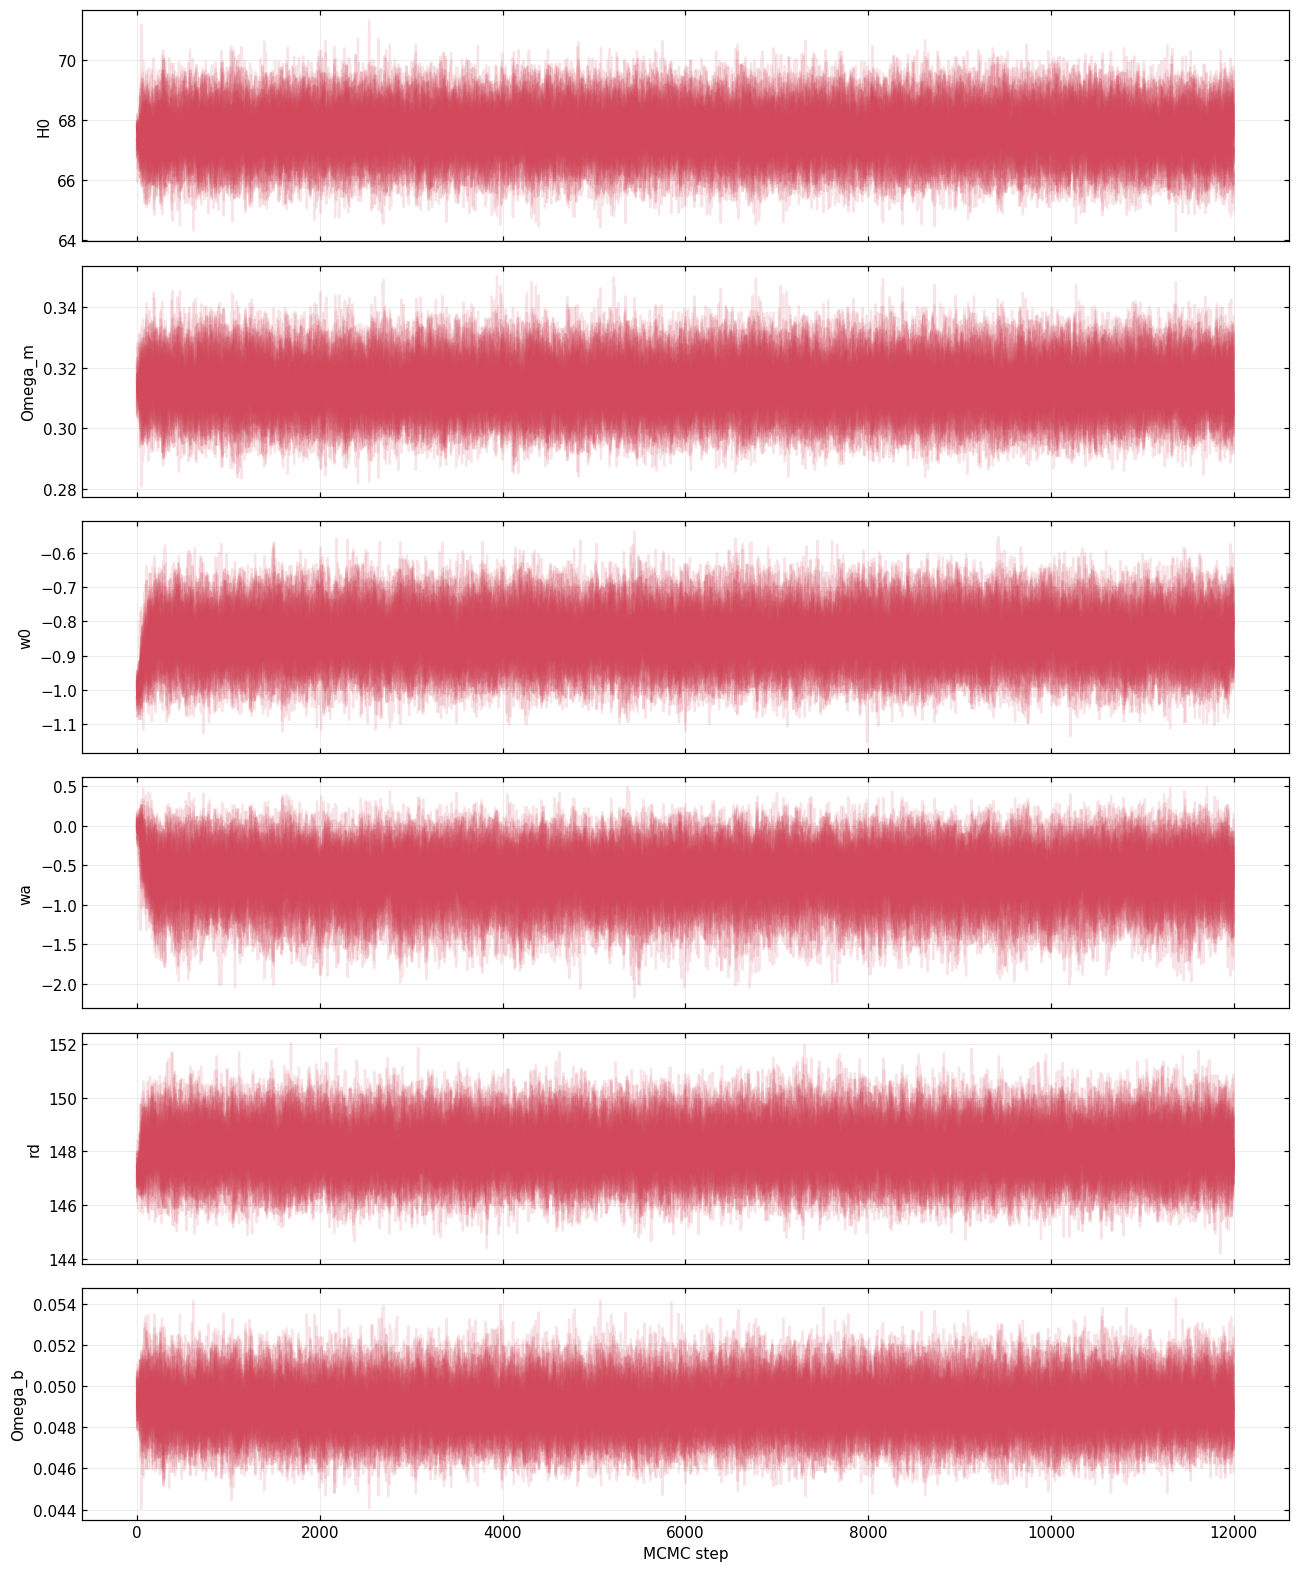

In [11]:
fig = fit.plots.chain()
savefig(fig, "chain")


saved corner.svg (2.04 MB)


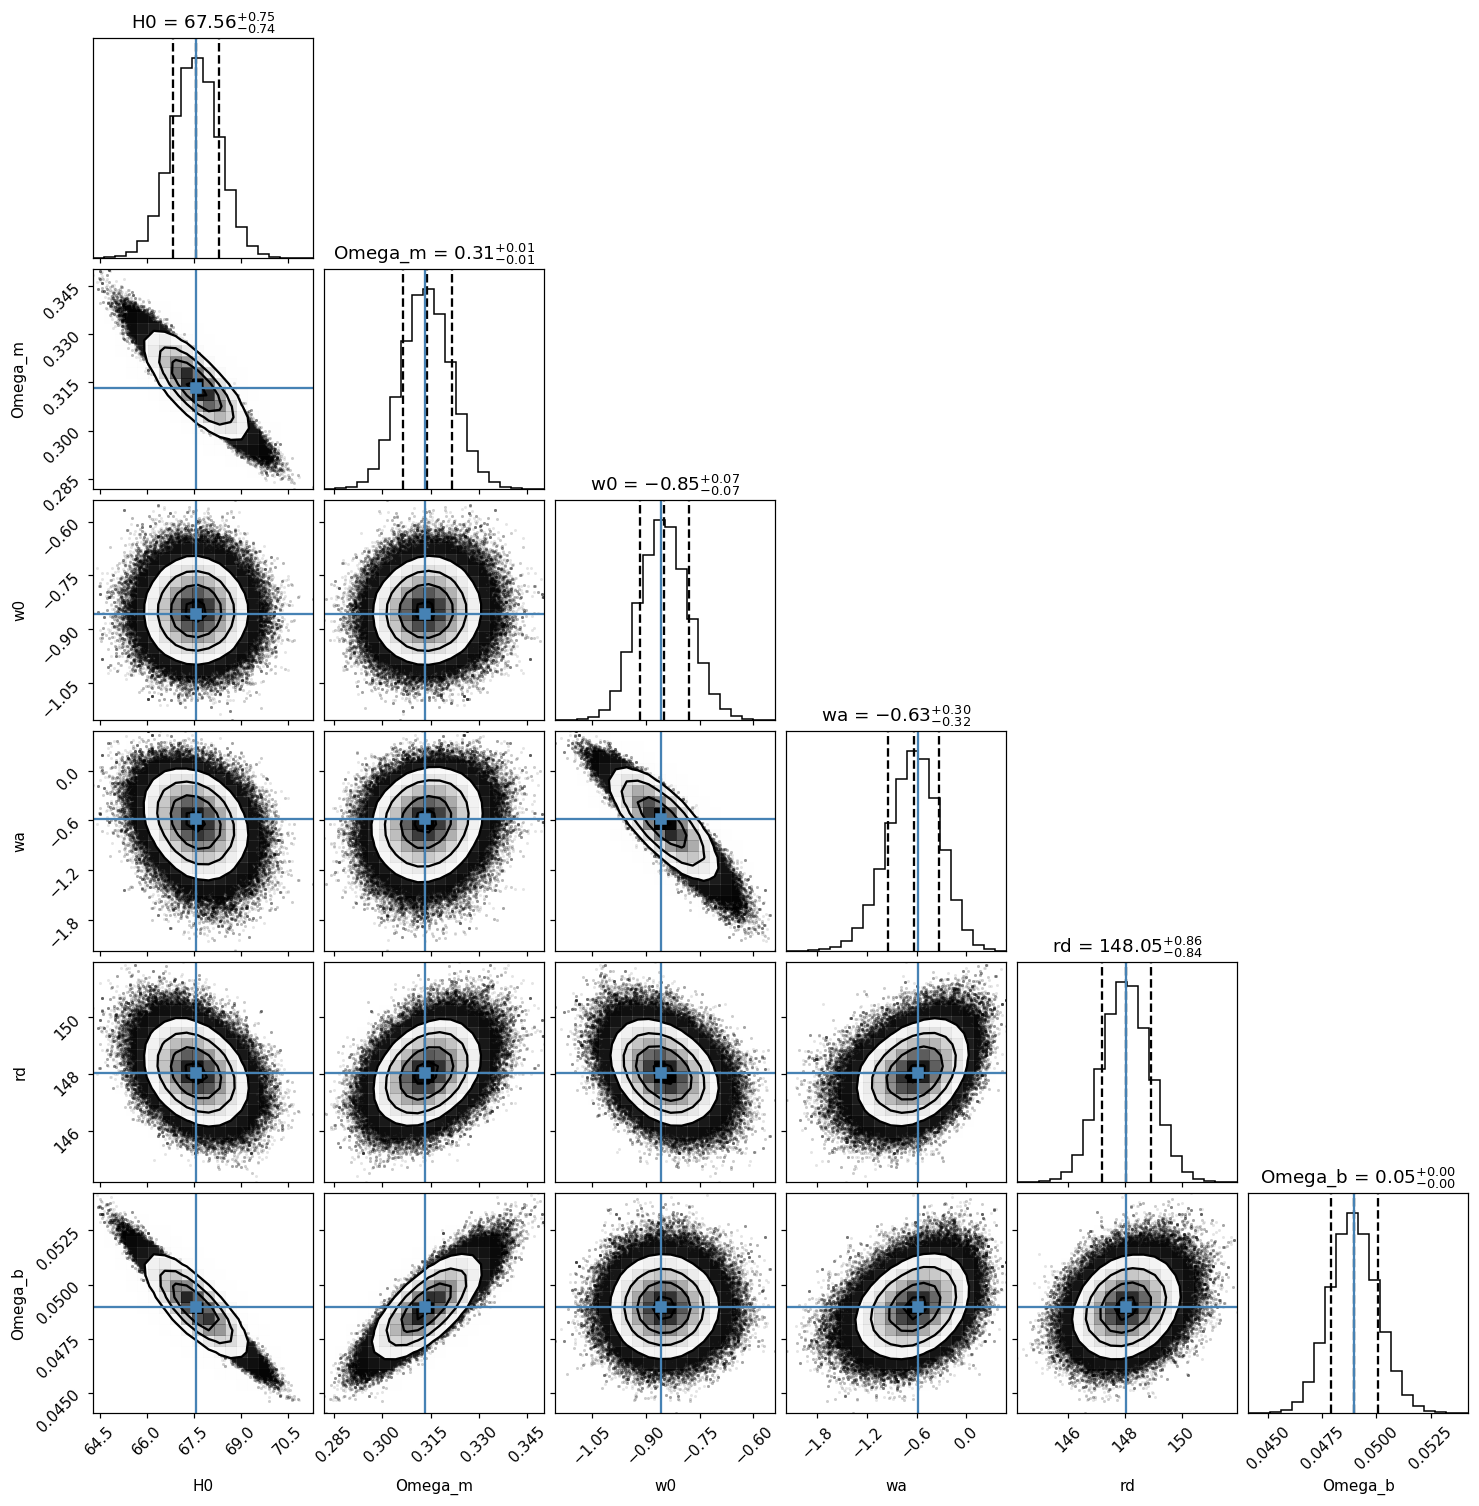

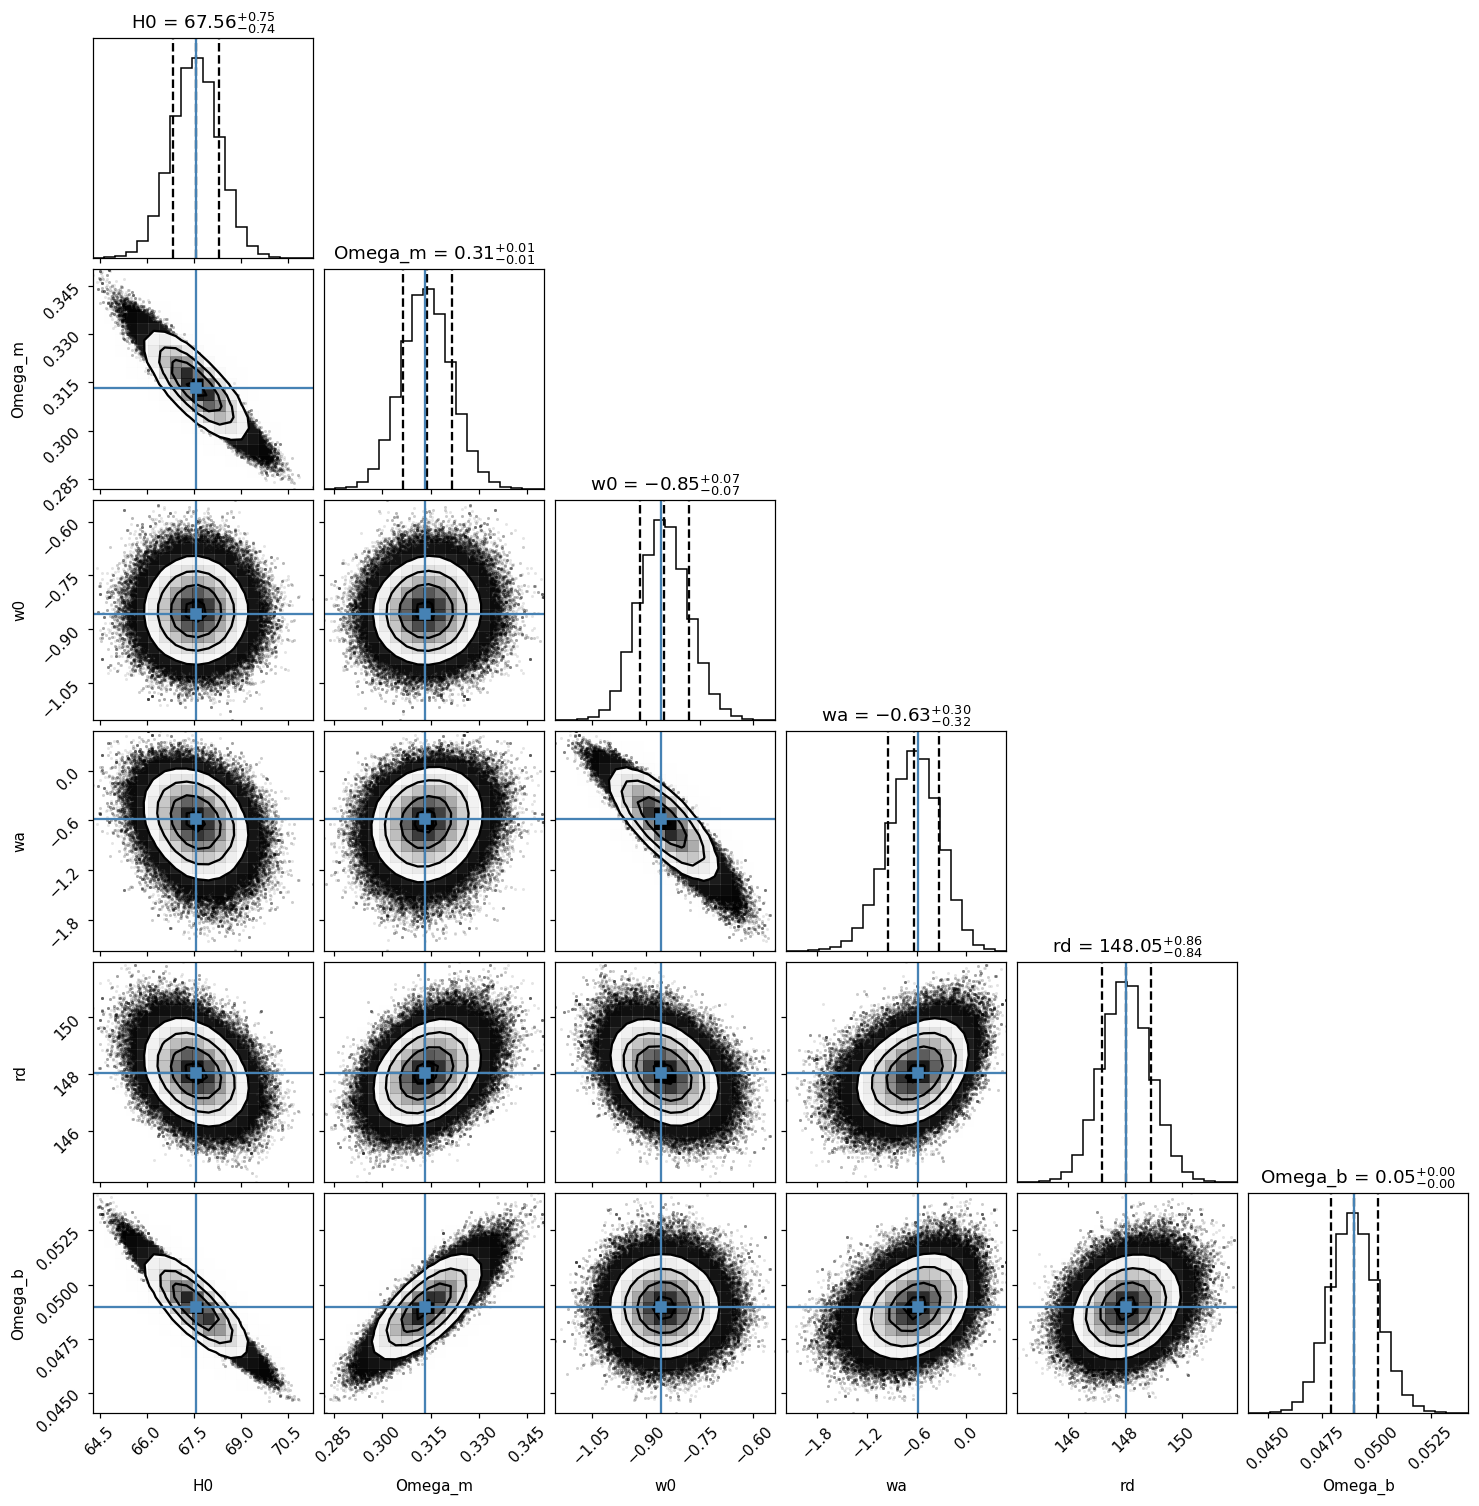

In [12]:
fig = fit.plots.corner(truths=[
    fit.best_fit_params["H0"],
    fit.best_fit_params["Omega_m"],
    fit.best_fit_params["w0"],
    fit.best_fit_params["wa"],
    fit.best_fit_params["rd"],
    fit.best_fit_params["Omega_b"],
])
savefig(fig, "corner")


## 8. Data vs. model: the standard cosmology figures

Each figure below shows the data against the model evaluated at the
posterior median, with a shaded 68% posterior-predictive band built from
random draws of the MCMC chain (not just a single best-fit curve).

saved hubble_diagram.svg (1.11 MB)


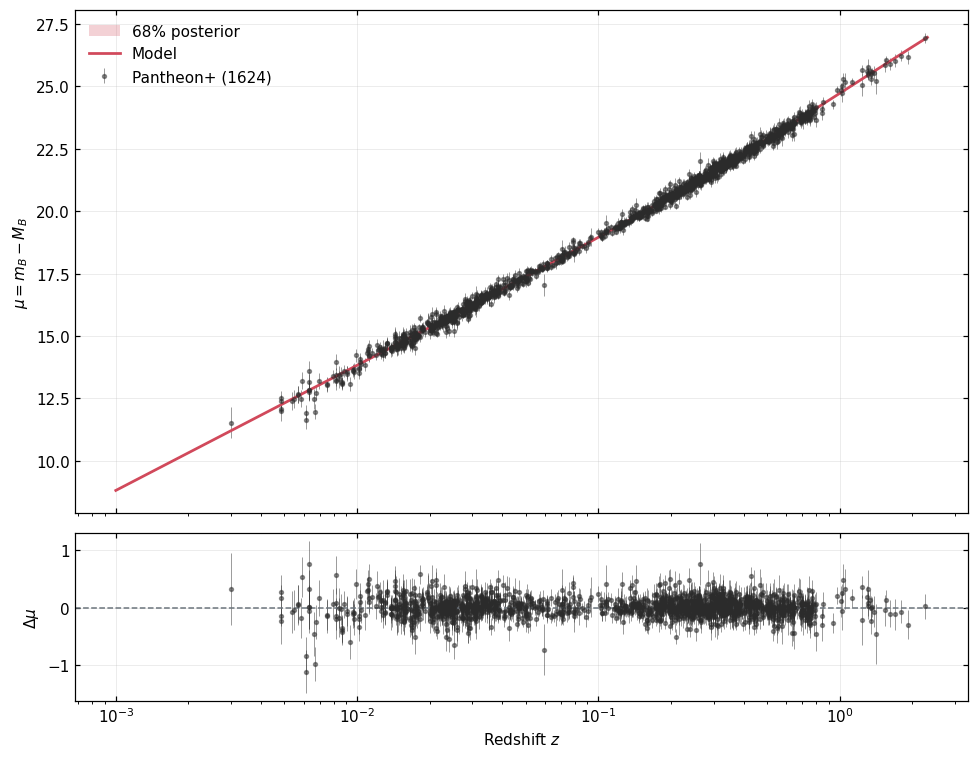

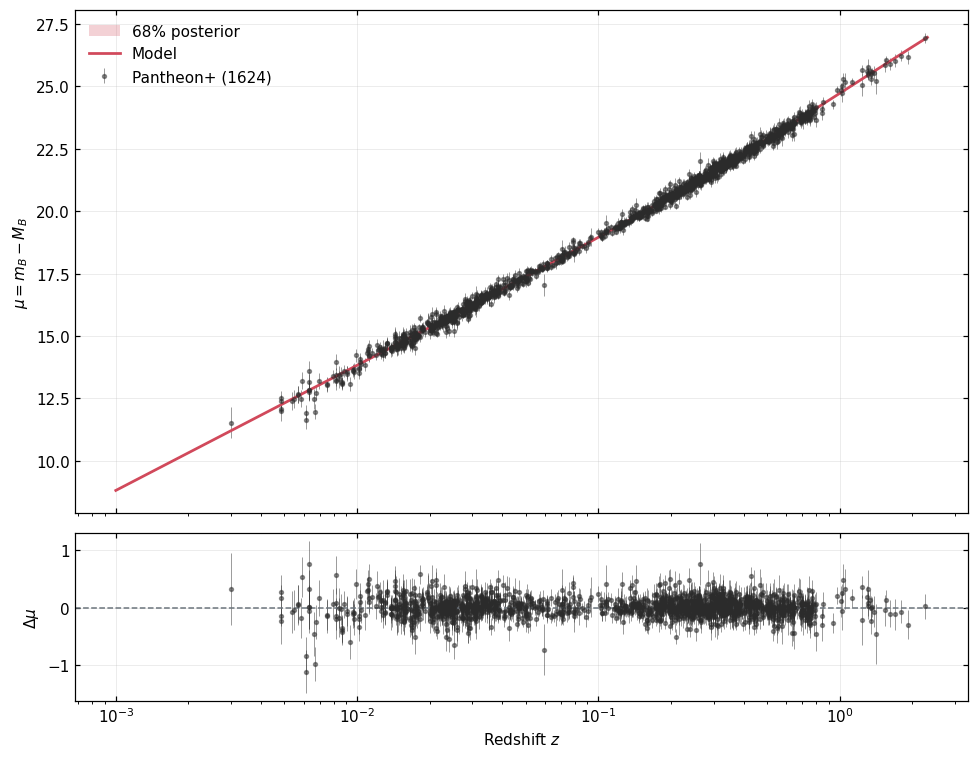

In [13]:
fig = fit.plots.hubble_diagram()
savefig(fig, "hubble_diagram")


saved hz.svg (0.06 MB)


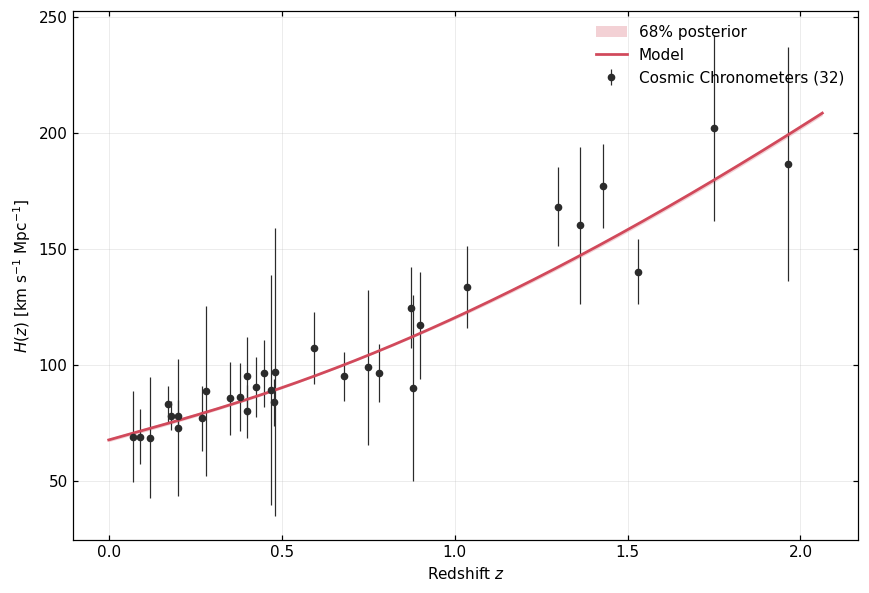

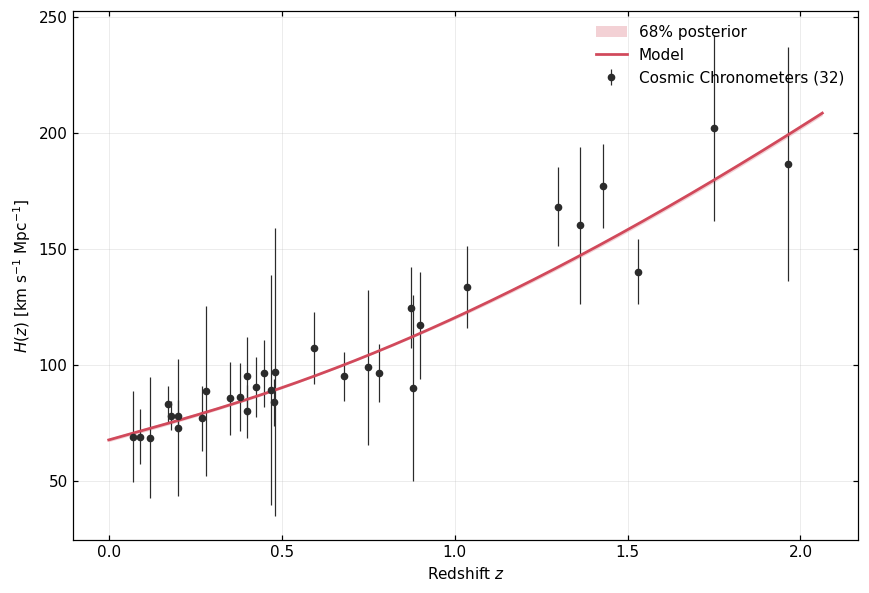

In [14]:
fig = fit.plots.hz()
savefig(fig, "hz")


saved bao_distances.svg (0.12 MB)


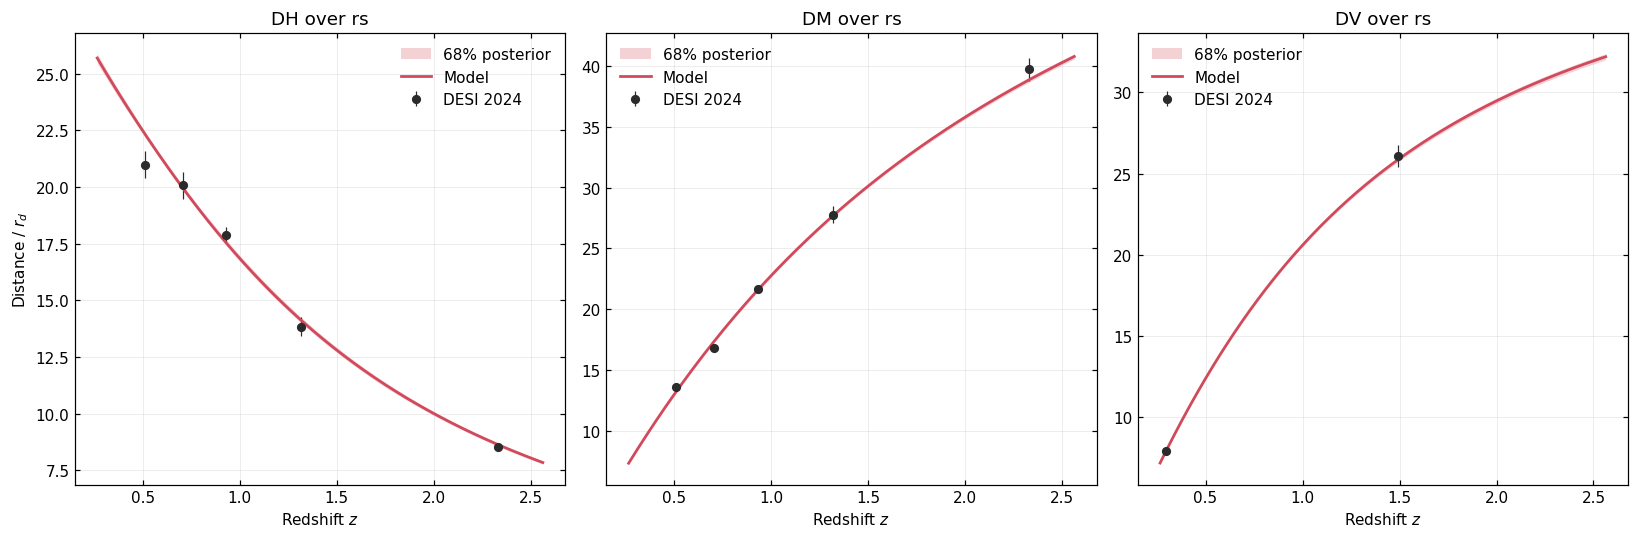

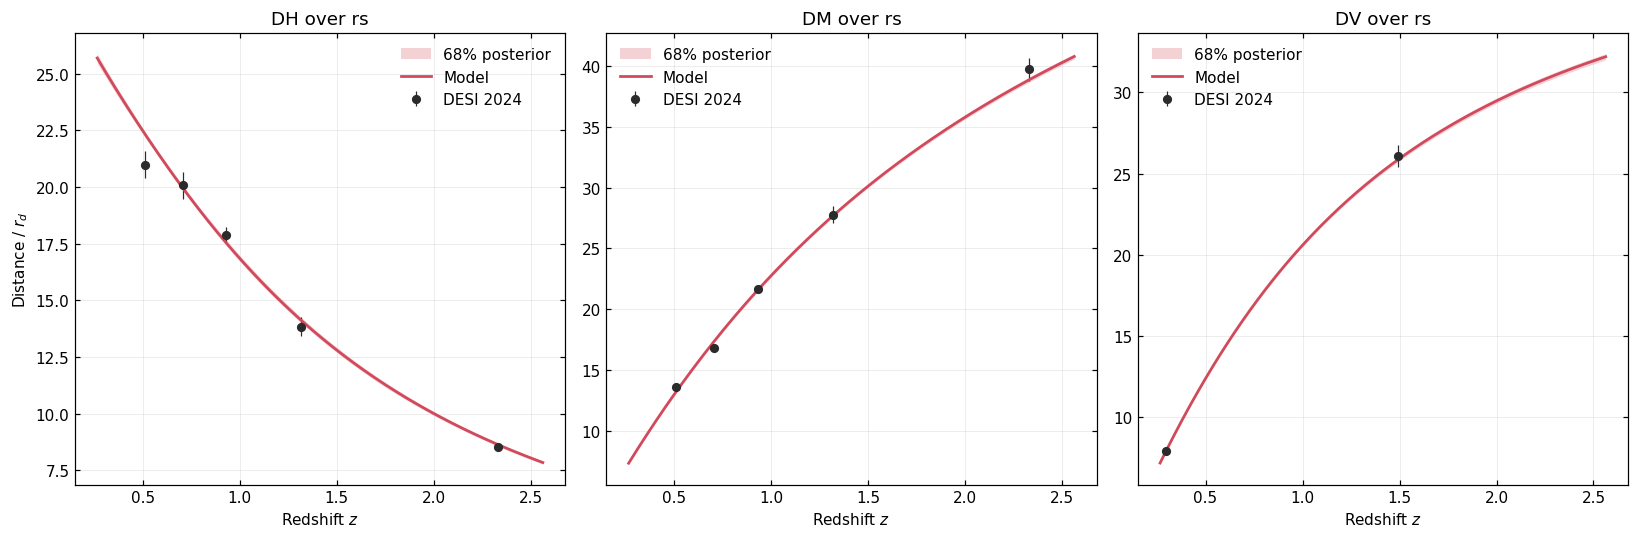

In [15]:
fig = fit.plots.bao_distances()
savefig(fig, "bao_distances")


## 9. Dark-energy equation of state $w(z)$ and the deceleration parameter

CPL's whole point is letting $w(z)$ evolve. The plot below shows the
posterior band for $w(z)$ against the $\Lambda$CDM reference line
$w=-1$, with any $w(z){=}{-1}$ crossing redshifts marked -- and the
deceleration parameter $q(z)$, with the deceleration/acceleration
transition redshift $z_t$ (where $q(z_t)=0$) marked.

saved w_of_z.svg (0.05 MB)


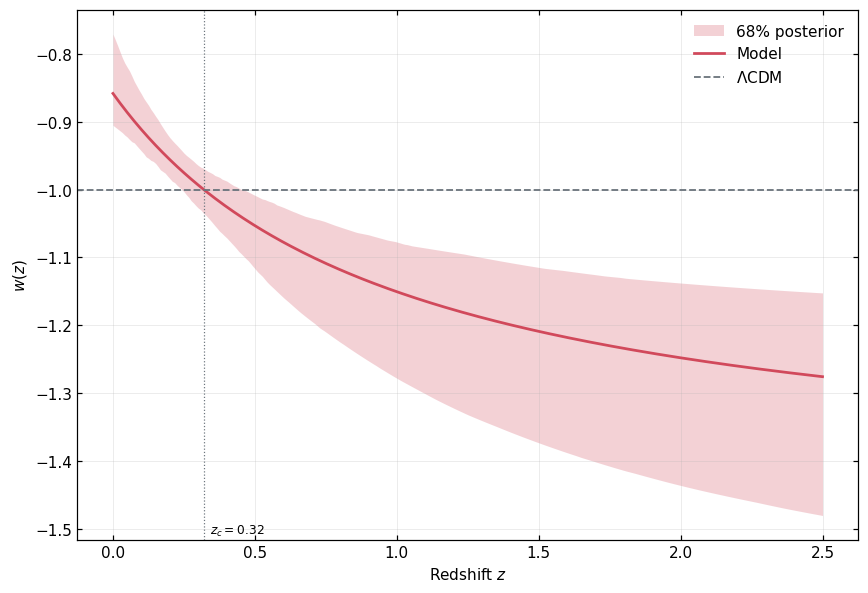

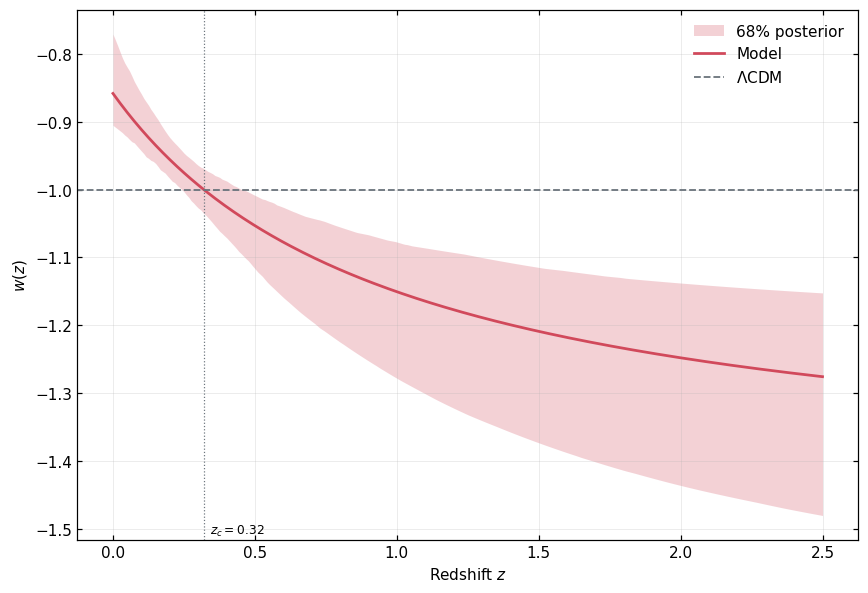

In [16]:
fig = fit.plots.w_of_z()
savefig(fig, "w_of_z")


### The $w_0$-$w_a$ plane

The same posterior seen the way the evolving-dark-energy literature
argues about it. Two lines cut the plane: $w_0 = -1$ (the equation of
state today) and $w_a = -1 - w_0$ (its high-redshift limit
$w_0 + w_a$). Together they separate the four cases -- **phantom**
($w < -1$ always), **quintessence** ($w > -1$ always), and the two
**quintom** regions, where $w(z)$ *crosses* $-1$ at some redshift.

That crossing is what makes the figure interesting: no single
canonical scalar field (nor a single phantom one) can cross $w = -1$,
so a posterior sitting in a quintom region needs something more --
two fields, a non-canonical kinetic term, or modified gravity.
$\Lambda$CDM is the single point $(-1, 0)$ where all of this
collapses to a cosmological constant, marked with a star.

`show_fractions=True` prints how much posterior probability actually
falls in each region, so "the contours sit in quintom-B" becomes a
number rather than an impression. Note the contours are **2D
credible regions** (68% and 95% of the samples), not 1D sigma
intervals -- in two dimensions the familiar $1\sigma$/$2\sigma$
contours enclose only 39% and 86.5%.

In [ ]:
fig = fit.plots.w0_wa_plane(show_fractions=True)
savefig(fig, "w0_wa_plane")


saved deceleration.svg (0.05 MB)


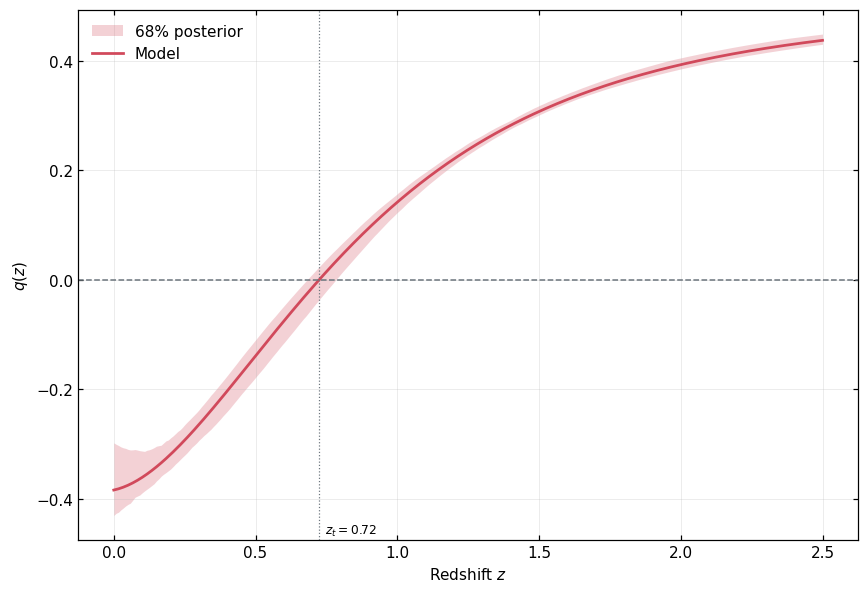

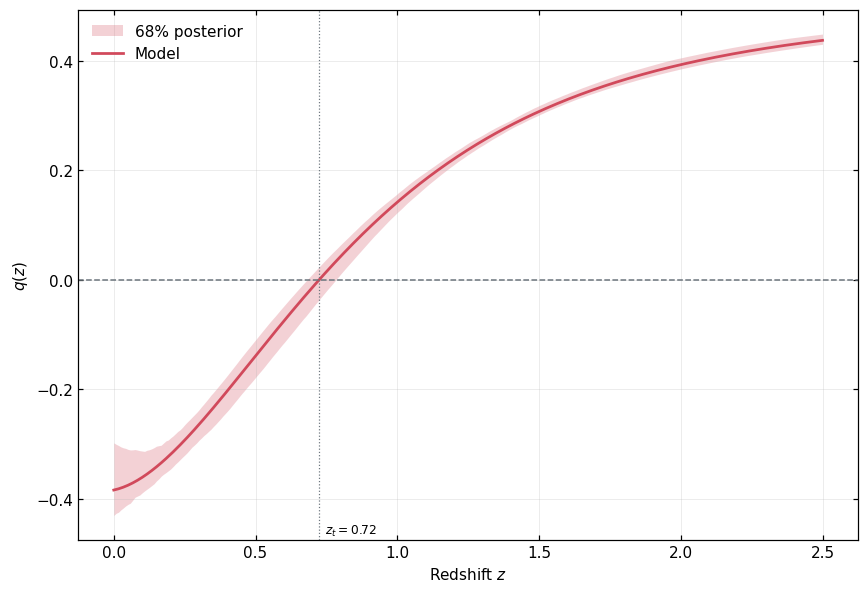

In [17]:
fig = fit.plots.deceleration()
savefig(fig, "deceleration")


### CPL-specific posterior diagnostics

`stats.cpl_diagnostics` turns the $(w_0, w_a)$ posterior into the
quantities dark-energy papers usually quote: the $w(z)=-1$ crossing
redshift distribution, its direction (quintessence-like $\to$
phantom-like or the reverse), and how many "sigma" away the $\Lambda$CDM
point $(w_0, w_a) = (-1, 0)$ sits from the 2D posterior.

In [18]:
samples = fit.samples_dict()

z_cross, frac_cross = cpl_diagnostics.crossing_redshift(samples["w0"], samples["wa"])
print(f"w(z)=-1 crossing: {frac_cross:.1%} of samples cross in [0, 2.5], "
      f"at z = {np.median(z_cross):.2f} (median) if they do")

if len(z_cross) > 0:
    direction = cpl_diagnostics.crossing_direction(samples["w0"], samples["wa"])
    print(f"  quintessence -> phantom: {direction['quintessence_to_phantom']:.1%}")
    print(f"  phantom -> quintessence: {direction['phantom_to_quintessence']:.1%}")

lcdm_distance = cpl_diagnostics.mahalanobis_from_lcdm(samples["w0"], samples["wa"])

# Report `sigma`, not `distance`. In 2D the Mahalanobis distance D is
# not a number of sigma: D^2 follows chi-square with 2 degrees of
# freedom, so D = 2.49 (not 2.00) is what encloses the "2 sigma"
# probability. Quoting D directly overstates the tension with LCDM.
print(f"\nLCDM point (w0, wa) = (-1, 0) vs the CPL posterior mean "
      f"{tuple(np.round(lcdm_distance['mean'], 3))}:")
print(f"  Mahalanobis distance D = {lcdm_distance['distance']:.2f} "
      f"(a distance, not a significance)")
print(f"  excluded at {lcdm_distance['confidence_level']:.2%} confidence "
      f"(p = {lcdm_distance['p_value']:.4f}, 2 d.o.f.)")
print(f"  => {lcdm_distance['sigma']:.2f} sigma equivalent")

w(z)=-1 crossing: 97.8% of samples cross in [0, 2.5], at z = 0.31 (median) if they do
  quintessence -> phantom: 99.3%
  phantom -> quintessence: 0.7%

LCDM point (w0, wa) = (-1, 0) vs the CPL posterior mean (np.float64(-0.849), np.float64(-0.639)):
  Mahalanobis distance D = 2.20 (a distance, not a significance)
  excluded at 91.07% confidence (p = 0.0893, 2 d.o.f.)
  => 1.70 sigma equivalent


## 10. Model comparison: CPL vs. flat $\Lambda$CDM

Is the extra freedom of CPL ($w_0$, $w_a$) actually preferred by the
data over flat $\Lambda$CDM, once model complexity is penalized? Fit
$\Lambda$CDM to the *same* four datasets -- with the *same* other free
parameters ($H_0$, $\Omega_m$, $r_d$, $\Omega_b$), so it's genuinely
CPL's nested special case at $w_0=-1,\ w_a=0$ and not a smaller,
differently-configured fit -- and compare with AIC, BIC, and a
likelihood-ratio test.

In [19]:
fit_lcdm = Fitter(
    model=LCDM,
    datasets=["cc", "desi", "pantheon", "planck"],
    free_params=["H0", "Omega_m", "rd", "Omega_b"],
    initial={"H0": 67.4, "Omega_m": 0.315, "rd": 147.1, "Omega_b": 0.0493},
)

fit_lcdm.run_mcmc(
    nwalkers=32, nsteps=8000, burnin=1500, seed=SEEDS["lcdm_joint"],
    progress=True,
    save=CHAIN_DIR / "lcdm.h5",
)
fit_lcdm.best_fit()

print(f"LCDM  chi2_min = {fit_lcdm.best_fit_chi2:.2f}  ({fit_lcdm.ndim} free parameters)")
print(f"CPL   chi2_min = {fit.best_fit_chi2:.2f}  ({fit.ndim} free parameters)")

100%|██████████| 8000/8000 [02:17<00:00, 58.07it/s]


LCDM  chi2_min = 1485.55  (4 free parameters)
CPL   chi2_min = 1480.85  (6 free parameters)


In [20]:
comparison = model_comparison.compare_models(
    name_null="LCDM",
    chi2_null=fit_lcdm.best_fit_chi2,
    k_null=fit_lcdm.ndim,
    name_alt="CPL",
    chi2_alt=fit.best_fit_chi2,
    k_alt=fit.ndim,
    n_data=fit.n_data,
)

for name in ("LCDM", "CPL"):
    row = comparison[name]
    print(f"{name:>5s}:  chi2={row['chi2']:8.2f}   AIC={row['AIC']:8.2f}   BIC={row['BIC']:8.2f}")

print(f"\ndelta_AIC (LCDM - CPL) = {comparison['delta_AIC']:+.2f}   "
      f"(positive favors CPL)")
print(f"delta_BIC (LCDM - CPL) = {comparison['delta_BIC']:+.2f}   "
      f"(BIC penalizes extra parameters more strongly than AIC)")

lrt = comparison["likelihood_ratio_test"]
print(f"\nLikelihood-ratio test: delta_chi2={lrt['delta_chi2']:.2f} "
      f"(delta_k={lrt['delta_k']}), p={lrt['p_value']:.3f}, "
      f"{lrt['sigma']:.2f} sigma preference for CPL over LCDM")

 LCDM:  chi2= 1485.55   AIC= 1493.55   BIC= 1515.24
  CPL:  chi2= 1480.85   AIC= 1492.85   BIC= 1525.38

delta_AIC (LCDM - CPL) = +0.70   (positive favors CPL)
delta_BIC (LCDM - CPL) = -10.14   (BIC penalizes extra parameters more strongly than AIC)

Likelihood-ratio test: delta_chi2=4.70 (delta_k=2), p=0.095, 1.31 sigma preference for CPL over LCDM


A modest AIC/BIC improvement or a low-significance likelihood-ratio
result here is not a discovery of evolving dark energy -- it just means
the data don't yet strongly prefer one model over the other. Unlike
`cpl_mcmc_analysis.ipynb`, Planck is now part of the joint fit itself
(not a separate check), which is closer to how DESI's own 2024 CPL
analysis is actually done -- combining BAO with CMB and SN
compilations, where a few-sigma preference for evolving dark energy
shows up in some dataset combinations.

## 11. CPL vs. flat $\Lambda$CDM: side-by-side comparison plots

The AIC/BIC/likelihood-ratio numbers above say *whether* CPL is
statistically preferred; these figures show *what that difference
actually looks like*. Every `fit.plots.*` figure has a `compare_*`
counterpart that overlays this fit's curve with one or more other
models' curves on the same data/axes -- `fit.plots.compare_hz(other_fits=fit_lcdm)`
here, since `fit_lcdm` was already built and MCMC-fit above for the
model-comparison section. (Left on its own, `compare_hz()` etc. would
auto-build a quick best-fit-only $\Lambda$CDM reference for exactly
this comparison -- passing `fit_lcdm` explicitly just reuses the full
MCMC posterior we already have instead.) This works for any model
CosmoFit knows about (built-in or [custom](https://github.com/salihyesil59/CosmoFit#custom-models)),
and for more than two at once via `other_fits=[fit_a, fit_b, ...]`.

saved compare_hz.svg (0.07 MB)


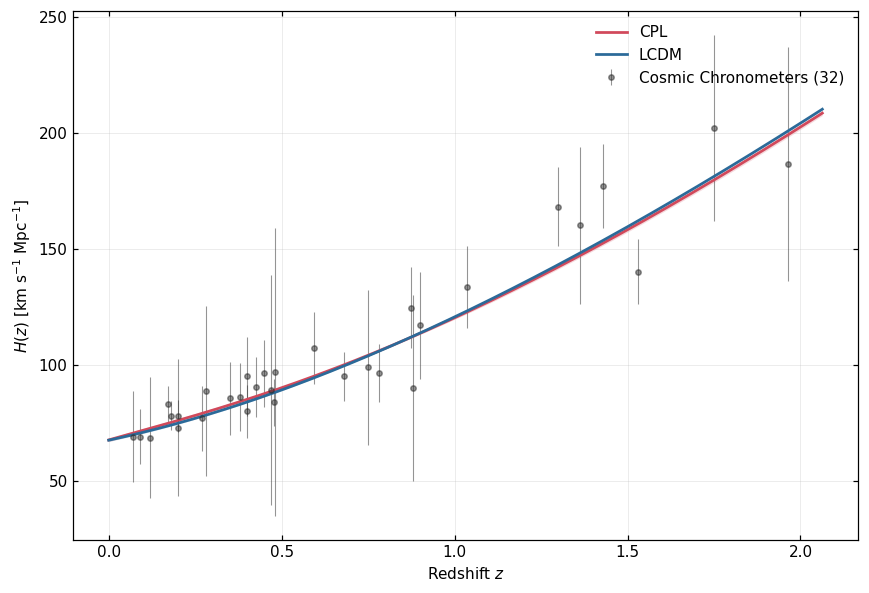

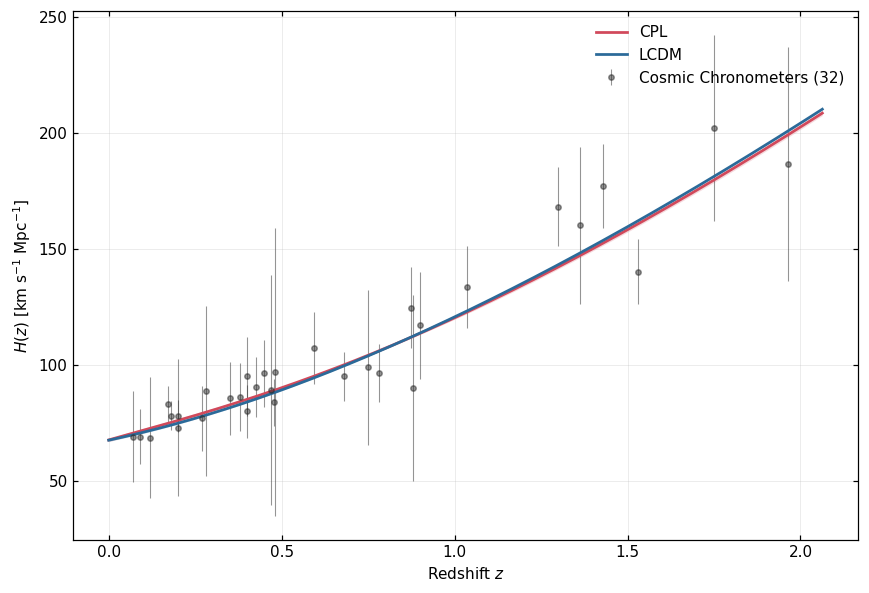

In [21]:
fig = fit.plots.compare_hz(other_fits=fit_lcdm, labels=["CPL", "LCDM"])
savefig(fig, "compare_hz")


saved compare_hubble_diagram.svg (0.59 MB)


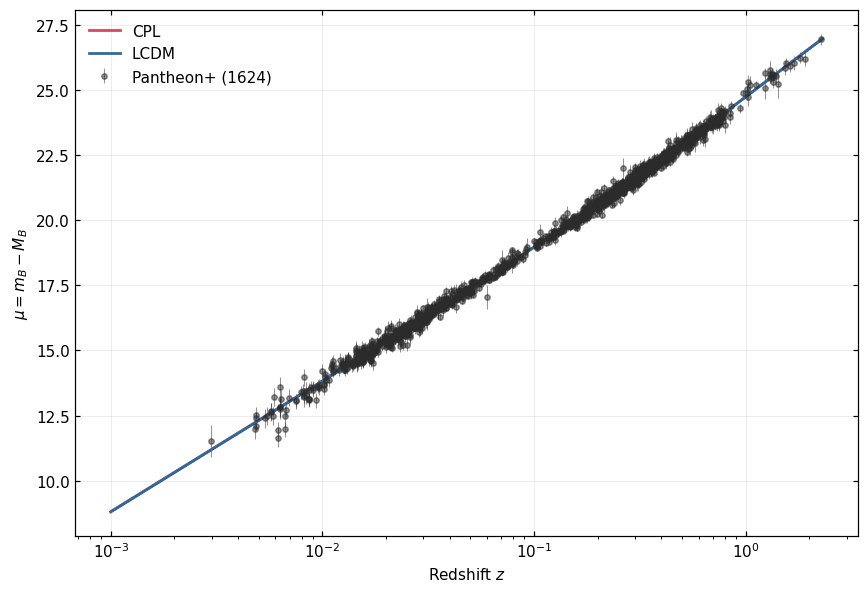

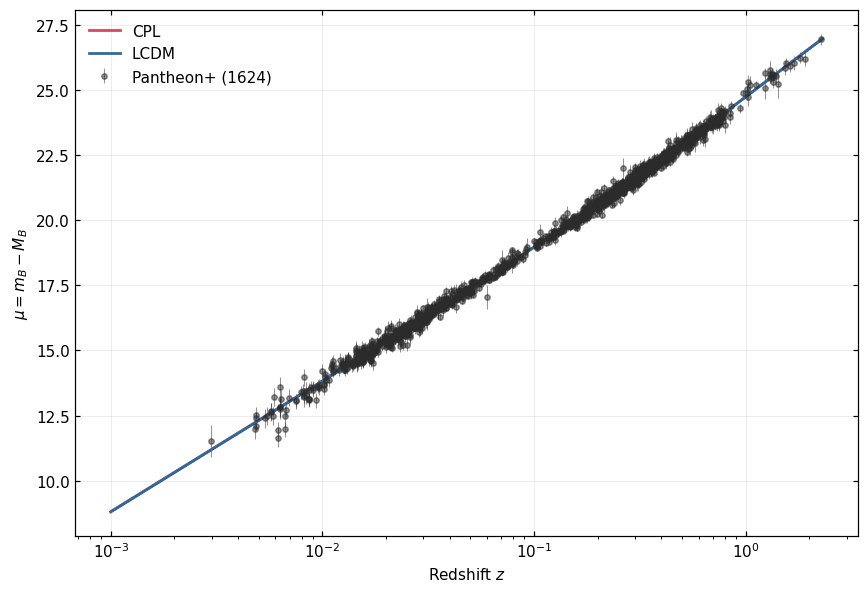

In [22]:
fig = fit.plots.compare_hubble_diagram(other_fits=fit_lcdm, labels=["CPL", "LCDM"])
savefig(fig, "compare_hubble_diagram")


saved compare_w_of_z.svg (0.06 MB)


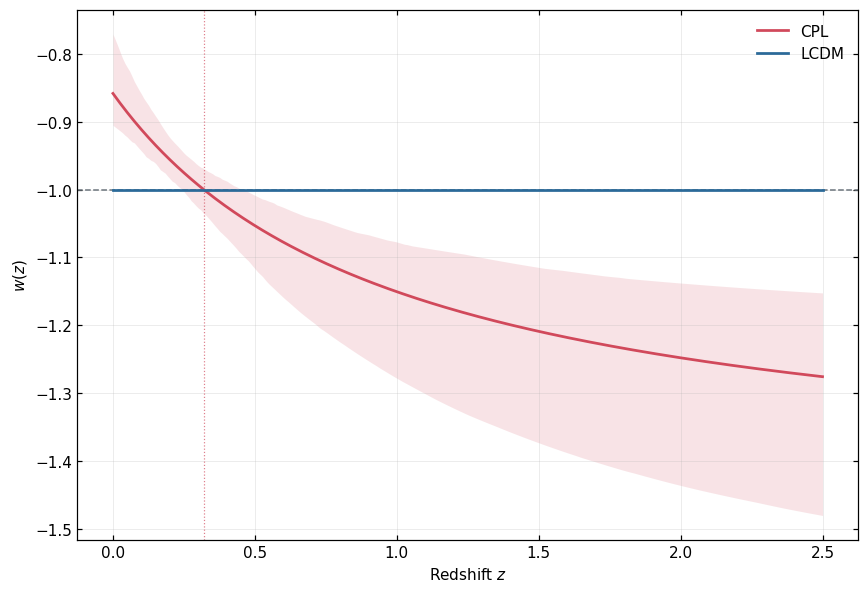

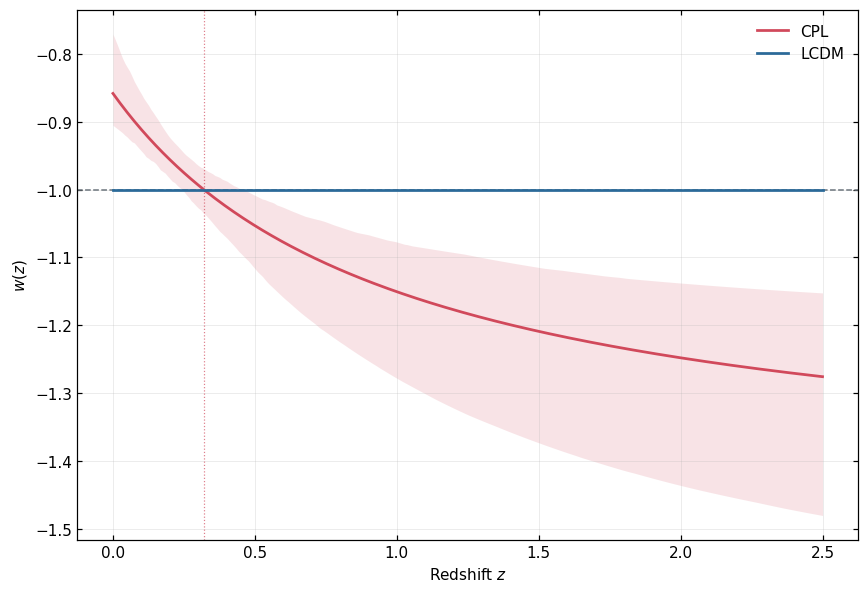

In [23]:
fig = fit.plots.compare_w_of_z(other_fits=fit_lcdm, labels=["CPL", "LCDM"])
savefig(fig, "compare_w_of_z")


saved compare_deceleration.svg (0.06 MB)


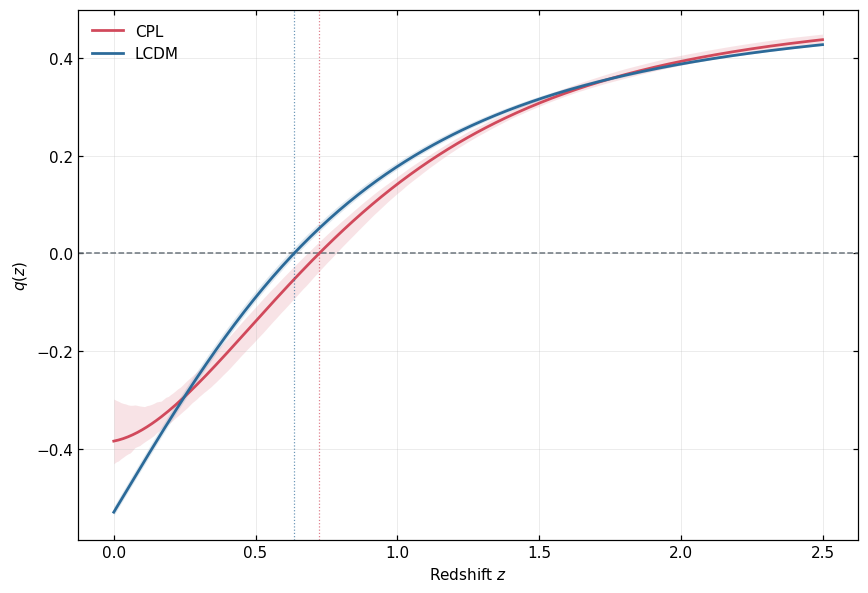

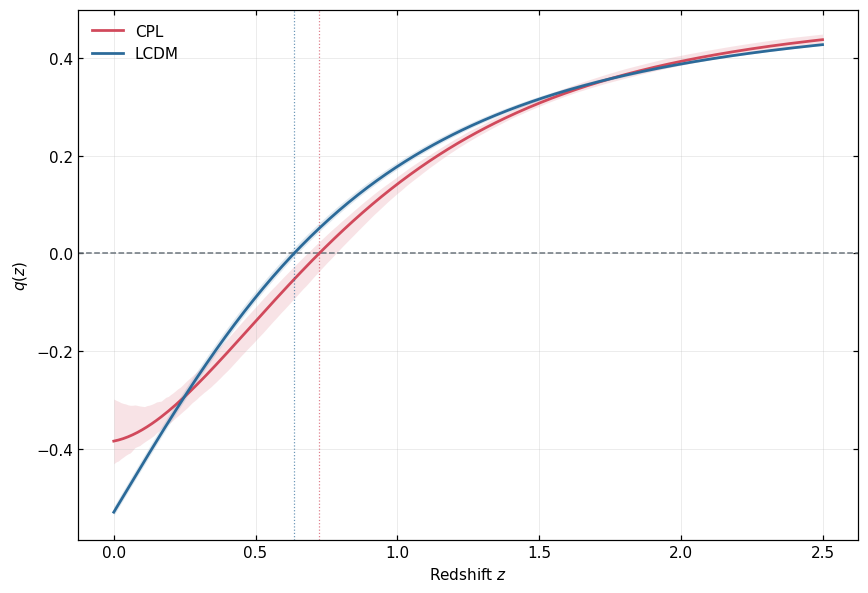

In [24]:
fig = fit.plots.compare_deceleration(other_fits=fit_lcdm, labels=["CPL", "LCDM"])
savefig(fig, "compare_deceleration")


Each curve above marks its own deceleration/acceleration transition redshift $z_t$ (where $q(z_t)=0$) -- CPL's evolving $w(z)$ shifts $z_t$ relative to $\Lambda$CDM's, which is exactly the kind of difference AIC/BIC alone don't show.

In [25]:
# z_t and q0 are functions of the whole expansion history, not of any
# single parameter, so `stats.derived` gets their posteriors by pushing
# every MCMC sample back through each model's own E(z)/dE(z)dz. That
# matters: evaluating them once at the best fit gives no error bar, and
# because q(z) is nonlinear in the parameters, the value at the median
# parameters is not the median of the derived posterior either.
#
# Unlike `cpl_diagnostics` (closed-form in CPL's w0/wa), this works for
# every model -- which is what lets LCDM be handled by the same call.

from CosmoFit.stats import derived

for label, this_fit in [("CPL", fit), ("LCDM", fit_lcdm)]:

    z_t = derived.summarize(derived.transition_redshift(this_fit))
    q0 = derived.summarize(derived.deceleration_today(this_fit))

    print(f"{label:>5}:  z_t = {z_t['median']:.4f} "
          f"+{z_t['plus']:.4f}/-{z_t['minus']:.4f}"
          f"   [95%: {z_t['lower95']:.3f}, {z_t['upper95']:.3f}]")
    print(f"{'':>5}   q0  = {q0['median']:+.4f} "
          f"+{q0['plus']:.4f}/-{q0['minus']:.4f}"
          f"   [95%: {q0['lower95']:+.3f}, {q0['upper95']:+.3f}]")

# Cross-check: for flat LCDM, q(z_t)=0 has the closed form
# z_t = (2 Omega_Lambda / Omega_m)^(1/3) - 1.
Om = fit_lcdm.samples_dict()["Omega_m"]
check = derived.summarize((2.0 * (1.0 - Om) / Om) ** (1.0 / 3.0) - 1.0)
print(f"\nLCDM analytic cross-check: z_t = {check['median']:.4f} "
      f"+{check['plus']:.4f}/-{check['minus']:.4f}")

  CPL:  z_t = 0.7301 +0.0474/-0.0530   [95%: 0.625, 0.819]
        q0  = -0.3742 +0.0693/-0.0715   [95%: -0.510, -0.224]
 LCDM:  z_t = 0.6336 +0.0165/-0.0172   [95%: 0.600, 0.667]
        q0  = -0.5283 +0.0104/-0.0097   [95%: -0.548, -0.508]

LCDM analytic cross-check: z_t = 0.6335 +0.0172/-0.0169


## 12. How well does the fit match Planck specifically?

Planck is one of four datasets in the joint fit above, not an
independent check this time (that's `cpl_mcmc_analysis.ipynb`) -- so
instead of a separate consistency check, this is the standardized-
residual ("pull") plot for how well the best-fit CPL point matches
Planck's own 3 compressed data points ($R$, $\ell_A$,
$\omega_b h^2$) specifically, in units of Planck's own uncertainty on
each. Since `"planck"` is one of `fit`'s own datasets now,
`fit.plots.planck_residuals()` works directly.

saved planck_residuals.svg (0.03 MB)


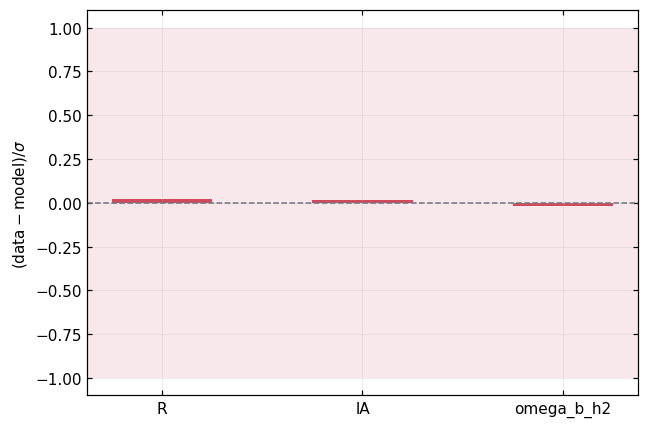

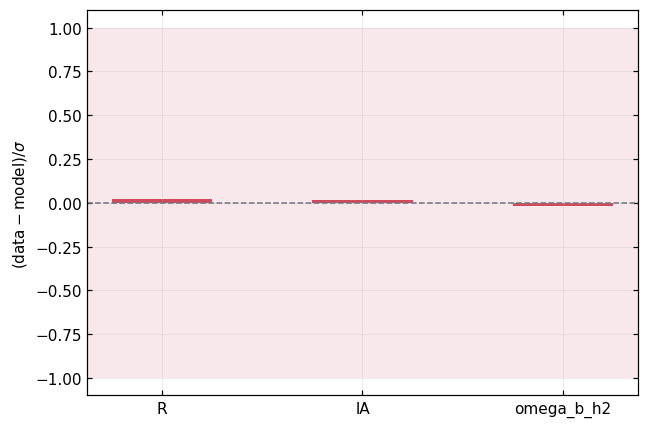

In [26]:
fig = fit.plots.planck_residuals()
savefig(fig, "planck_residuals")


## Summary

This notebook fit the CPL dark-energy model jointly to Cosmic
Chronometers, DESI BAO, Pantheon+ supernovae, and Planck's CMB distance
priors, with $r_d$ and $\Omega_b$ free (made constrainable by including
Planck) alongside $H_0$, $\Omega_m$, $w_0$, $w_a$, using a
publication-scale MCMC chain (`nwalkers=64`, `nsteps=12000`) evaluated
in parallel across every available CPU core. It checked chain
convergence, produced the standard cosmology-paper figures (Hubble
diagram, $H(z)$, BAO distances, $w(z)$ evolution, deceleration
parameter), compared CPL against flat $\Lambda$CDM (fit to the same
four datasets and free parameters bar $w_0$/$w_a$) with AIC/BIC/a
likelihood-ratio test and side-by-side comparison plots, and checked
the fit's match to Planck's own data points specifically.

If `fit.convergence()` still came back `False` at these settings,
`nsteps` needs to go higher -- rerun section 4 with a larger value (or
call `fit.run_mcmc(...)` again with more steps) and recheck.

See the [CosmoFit README](https://github.com/salihyesil59/CosmoFit) for
the full API, and `cpl_mcmc_analysis.ipynb` for the shorter,
Planck-as-independent-check variant of this analysis.

## Appendix: the $w_0$-$w_a$ plane on fixed axes

The same figure as in section 9, drawn on the axis ranges the
published versions of this plot use ($w_0 \in [-1.3, 0]$,
$w_a \in [-3, 1]$) rather than on ranges sized around this
particular posterior -- which is what makes it directly comparable
to the same figure in other papers, at the cost of a lot of empty
space if the contours happen to be tight.

`save_path` is relative to wherever the kernel was started (see the
note in section 1), so this writes `w0wa.svg` into the current
working directory rather than alongside the notebook's other
figures. Use `save_path=FIGURE_DIR / "w0wa.svg"` to put it with
them.


In [ ]:
fit.plots.w0_wa_plane(w0_range=(-1.3, 0.0), wa_range=(-3, 1), save_path="w0wa.svg")
